# BTSP on a linear track

* Linear track (periodic)
* Agent navigates in a specific direction (and later back and forth)
* Landmark object located partway along the track.
* Two-compartment pyramidal neuron layer (1 neuron):
  * Proximal input: uniformly distributed Gaussian place cells (plastic)
  * Distal input: Target landmark object-encoding cell (fixed)
  * Filtered distal self-inhibition
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox

from predhpc import plot_fcts, run_manager
from predhpc.util import ext_util, plot_util, params_util, animate_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("..", "results", "script_figures", "linear_track"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Hyperparameters and functions

In [5]:
env_params = params_util.get_env_params(
    environment="linear",
    init_env_object_prop=params_util.REL_ENV_OBJECT_POS,
)

agent_params = params_util.get_agent_params(
    environment="linear",
)

Pyr_params = params_util.get_Pyr_params(
    environment="linear",
    log_BTSP=True,
)

init_kwargs = {
    "env_params": env_params,
    "agent_params": agent_params,
    "Pyr_params": Pyr_params,
}

## 1. Initial direction

0it [00:00, ?it/s]

BTSP event recorded at step 525 (15.75 sec).
BTSP update applied at step 1219 (36.57 sec).
Speed mean: 24.61 cm/s, std: 5.38 cm/s.
Reached target 4 times.
Trajectory lengths (4): 39.17 +/- 8.01 sec each
Trajectory lengths (4): 1305.75 +/- 266.84 steps each
1 BTSP event triggered (allowed from step 0): occurred at step 525.
No weight normalization applied (max value of 0.8072 <= 1).


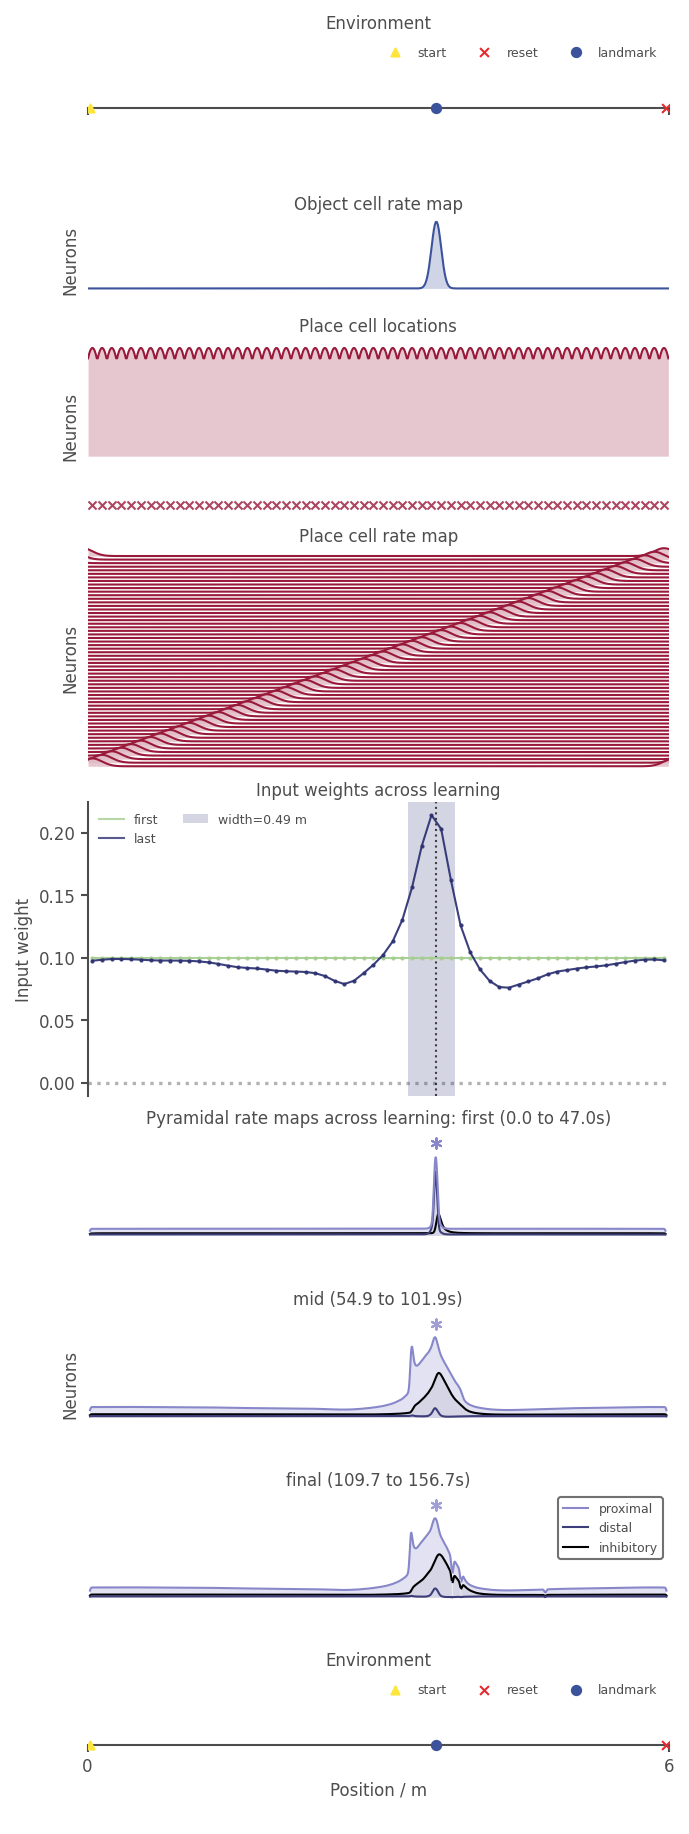

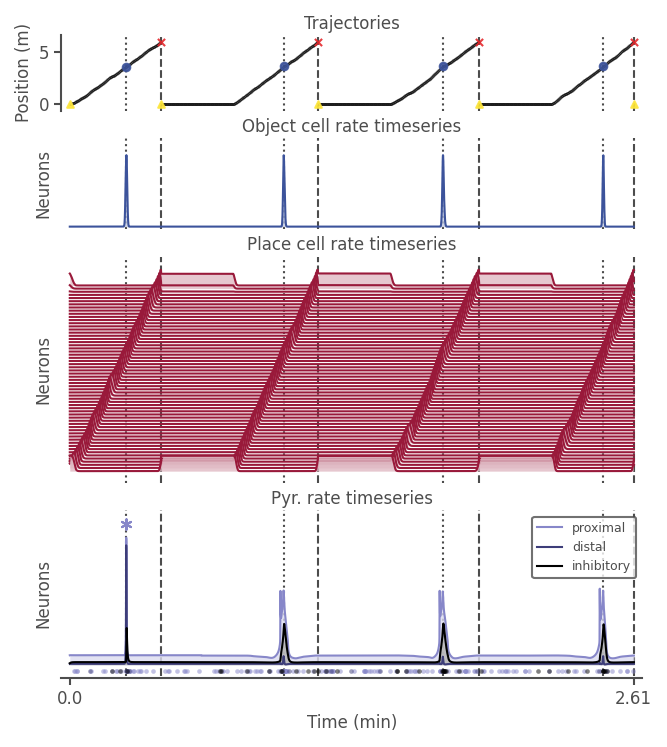

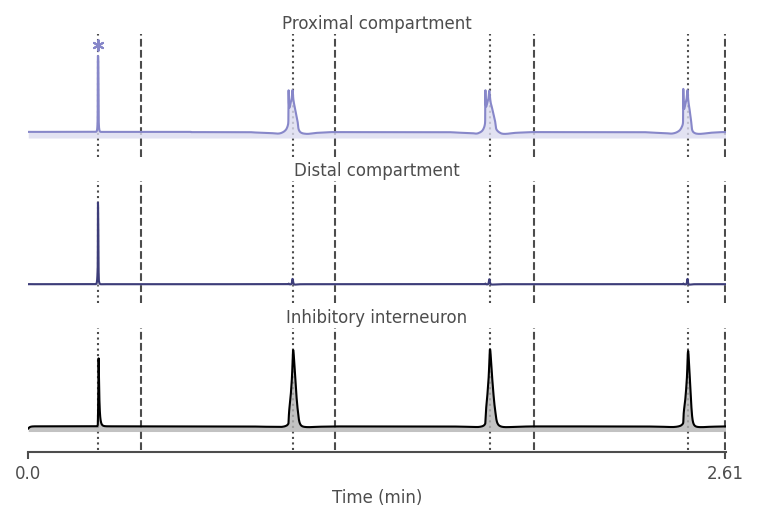

In [6]:
learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
    init_kwargs=init_kwargs,
    BTSP_on=None,
    num_traj_can_stop=4,
)

Pyrs = learner.Pyrs
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)
landmark_position = Ag.target_position

ts_axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyr_kwargs={"norm_by": "shared_max"})
for sub_ax in ts_axes.ravel():
    sub_ax.set_ylabel("")

spatial_axes.ravel()[-2].legend(loc="upper right")
time_axes.ravel()[-1].legend(loc="upper right")

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_time"] = time_axes
ALL_FIGURES["1-initial_timeseries"] = ts_axes

In [7]:
learner.Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.ProximalCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered.
No neuron had at least two BTSP updates triggered.


Speed mean: 24.61 cm/s, std: 5.38 cm/s.


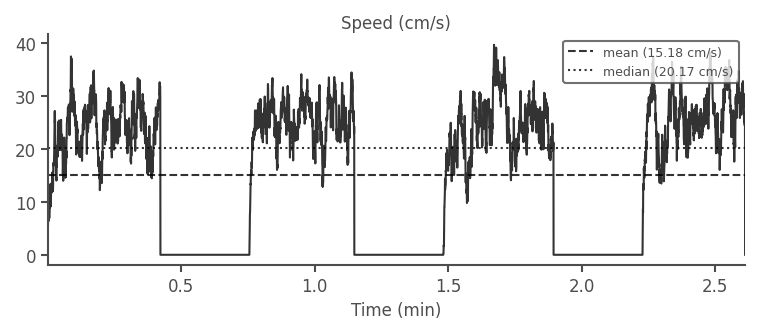

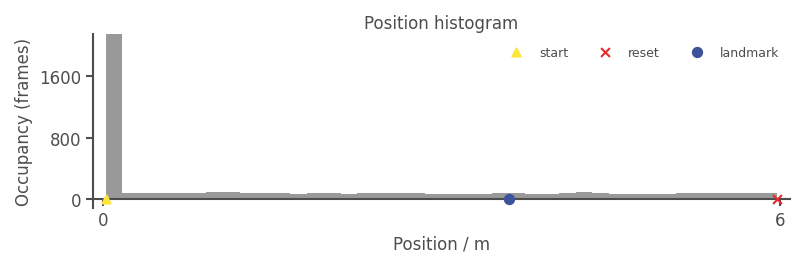

In [8]:
learner.Agent.log_speed_stats(ignore_near_zero=True)
sub_ax_speed = learner.Agent.plot_speed(mark_median=True, mark_mean=True)
sub_ax_occ = learner.Agent.plot_occupancy()

sub_ax_speed.legend(loc="upper right")

ALL_FIGURES["1-single_speed"] = sub_ax_speed
ALL_FIGURES["1-single_occupancy"] = sub_ax_occ

### Initial history-based and input-based rate maps

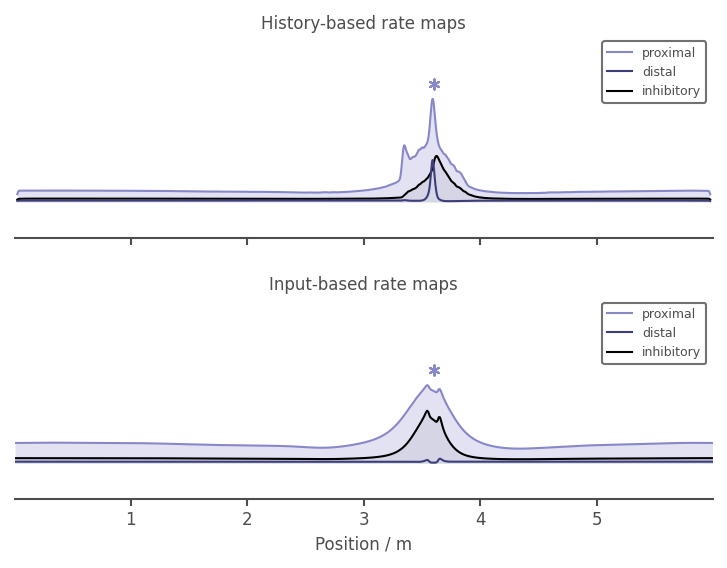

In [9]:
_, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True, gridspec_kw={"hspace": 0.3})
learner.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
ax1D[0].set_ylabel("")
ax1D[0].legend(loc="upper right")

learner.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Input-based rate maps");
ax1D[1].set_ylabel("")
ax1D[1].legend(loc="upper right")

ALL_FIGURES["1-initial_rate_maps"] = ax1D

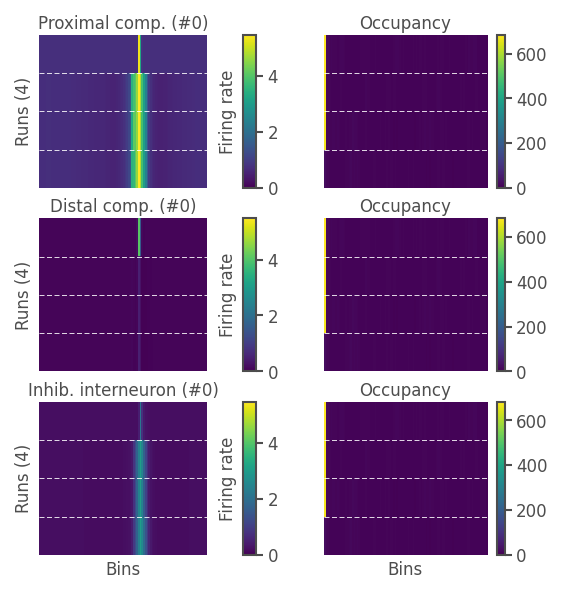

In [10]:
axes = learner.Pyrs.plot_binned_rates(mark_runs=True)

ALL_FIGURES["1-initial_binned_rates"] = axes

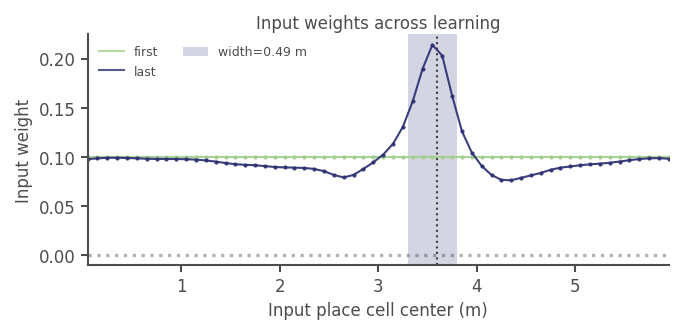

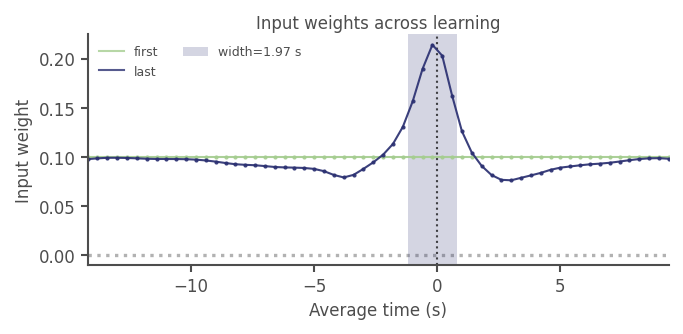

In [11]:
ws = [learner.Pyrs.ProximalCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_PFs(ws, PCs, plot_last_width=True)
sub_ax_time = plot_fcts.plot_1D_PFs(ws, PCs, time_axis=True, plot_last_width=True)

ALL_FIGURES["1-initial_weights"] = sub_ax
ALL_FIGURES["1-initial_weights_time"] = sub_ax_time

## Theoretical kernel

Update 1 regul.: 0.7871 (w)


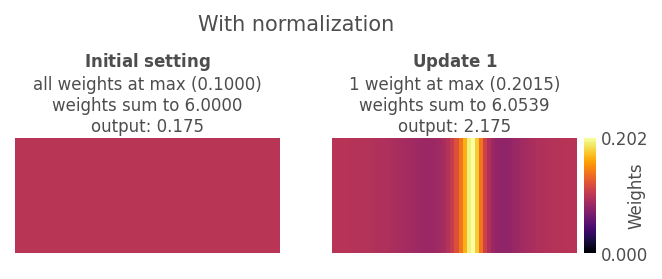

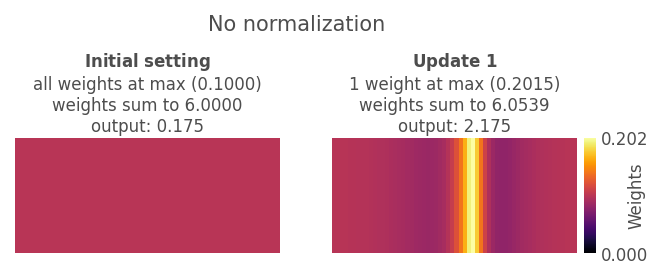

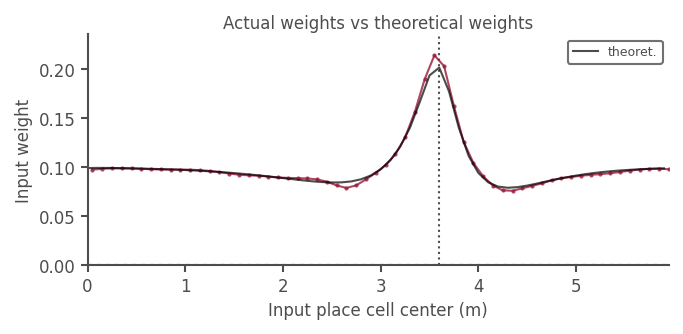

In [12]:
norm_theor_axes, no_norm_theor_axes, comp_sub_ax = plot_fcts.compare_theoretical_and_true_weights(
    Pyrs.ProximalCompartment,
    output_fr=4.2, # tuned to match actual weights
)

ALL_FIGURES["BTSP_kernel_norm"] = norm_theor_axes
ALL_FIGURES["BTSP_kernel"] = no_norm_theor_axes
ALL_FIGURES["1-initial_weights_compared"] = comp_sub_ax

### Initial direction inputs and activations

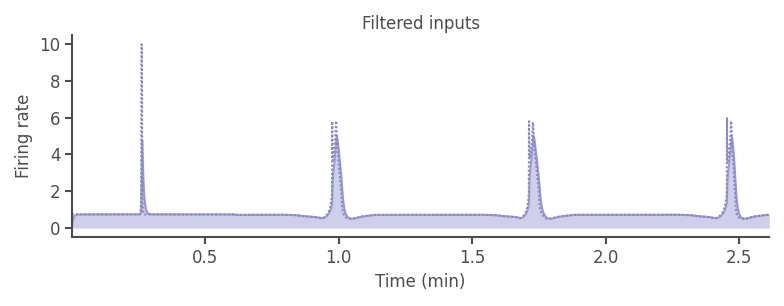

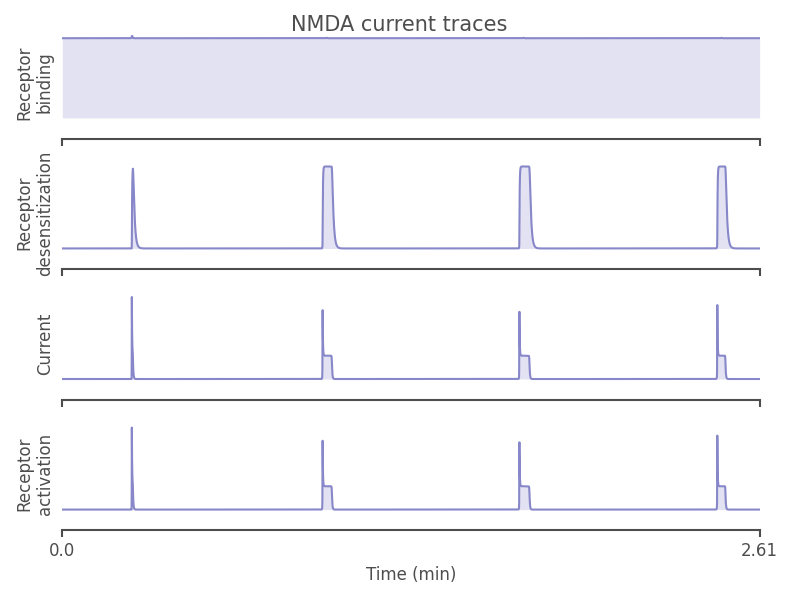

In [13]:
sub_ax, _ = learner.Pyrs.DistalInhibition.plot_filtered("Pyr_TwoComp_proximal")
ax1D = learner.Pyrs.ProximalCompartment.NMDACurrent.plot_timeseries(datatypes="all")

ALL_FIGURES["1-initial_filtered_inputs"] = sub_ax
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

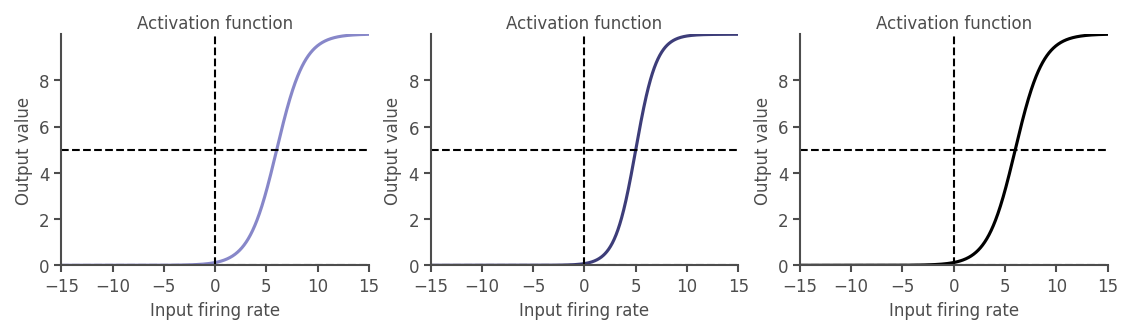

In [14]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
learner.Pyrs.ProximalCompartment.plot_activation_function(sub_ax=ax1D[0])
learner.Pyrs.DistalCompartment.plot_activation_function(sub_ax=ax1D[1])
learner.Pyrs.DistalInhibition.plot_activation_function(sub_ax=ax1D[2])

ALL_FIGURES["activation"] = ax1D

### Initial direction BTSP stats

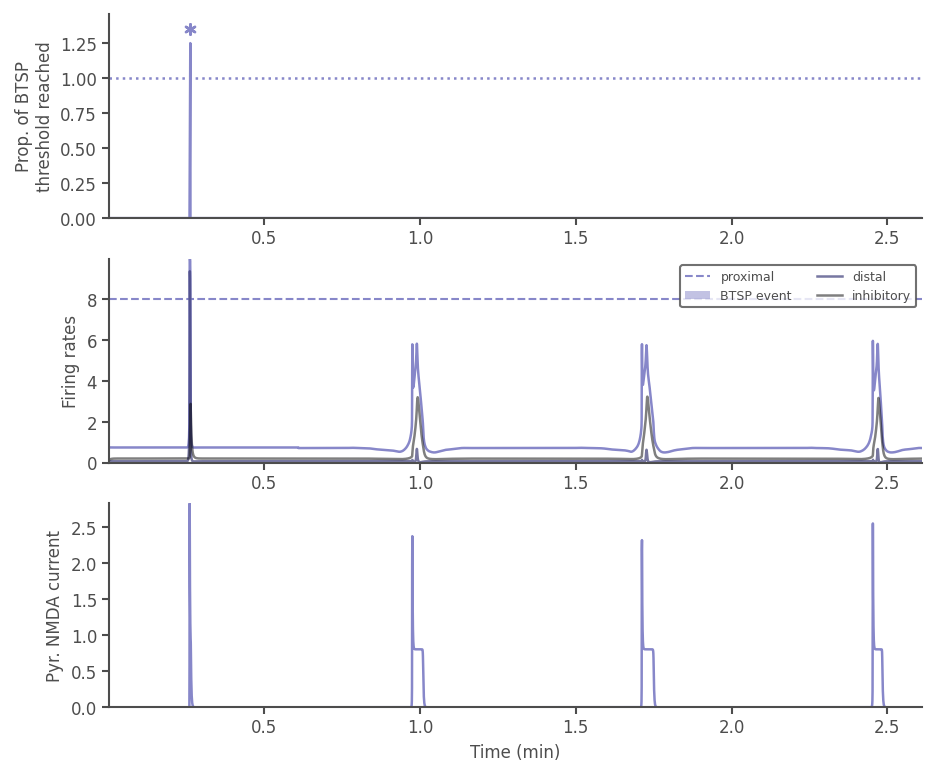

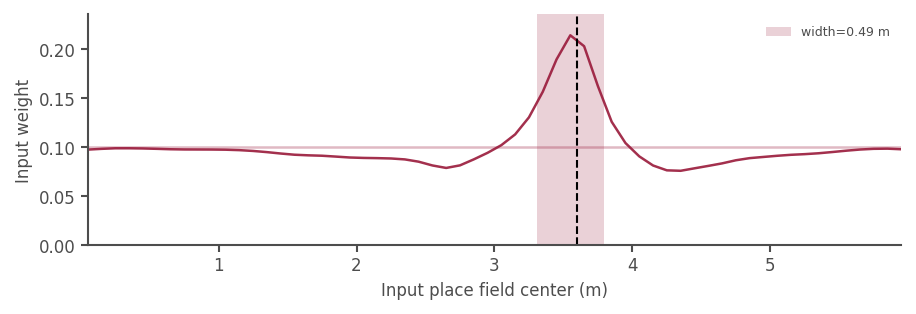

In [15]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner.Pyrs, 
    recorded_PFs=learner.get_recorded_weights()["weights"][:, 0], 
    target_position=landmark_position,
    plot_last_width=True,
    PF_type="weights",
)

ALL_FIGURES["1-initial_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["1-initial_PC_weights"] = PCs_sub_ax

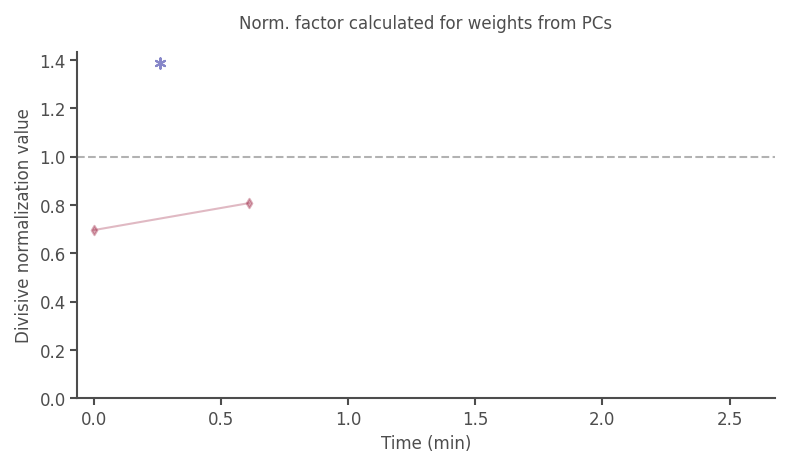

In [16]:
if learner.Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = learner.Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["1-initial_weight_norm_time"] = sub_ax

### Pre BTSP kernel
Plot eligibility trace equivalent.

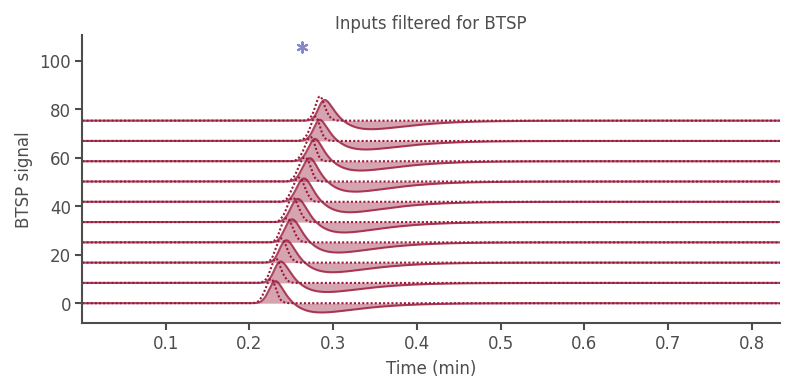

In [17]:
sub_ax = learner.Pyrs.ProximalCompartment.plot_filtered_for_BTSP("PCs", t_end=50, chosen_neurons=np.arange(30, 40))
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

### Post BTSP kernel

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered (num steps: 696).


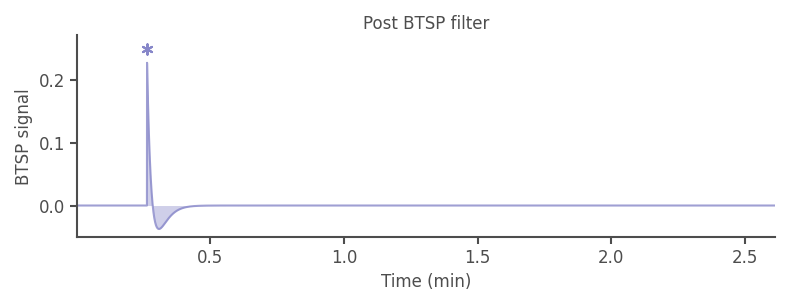

In [18]:
learner.Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner.Pyrs.ProximalCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

## 2. Shift landmark object
Landmark object shifted to a new location after initial BTSP learning.

0it [00:00, ?it/s]

BTSP event recorded at step 6502 (195.06 sec).
BTSP update applied at step 7196 (215.88 sec).
Speed mean: 24.55 cm/s, std: 5.43 cm/s.
Reached target 4 times.
Trajectory lengths (8): 41.73 +/- 6.25 sec each
Trajectory lengths (8): 1390.88 +/- 208.22 steps each
1 BTSP event triggered (allowed from step 5224): occurred at step 6502.
No weight normalization applied (max value of 0.8452 <= 1).


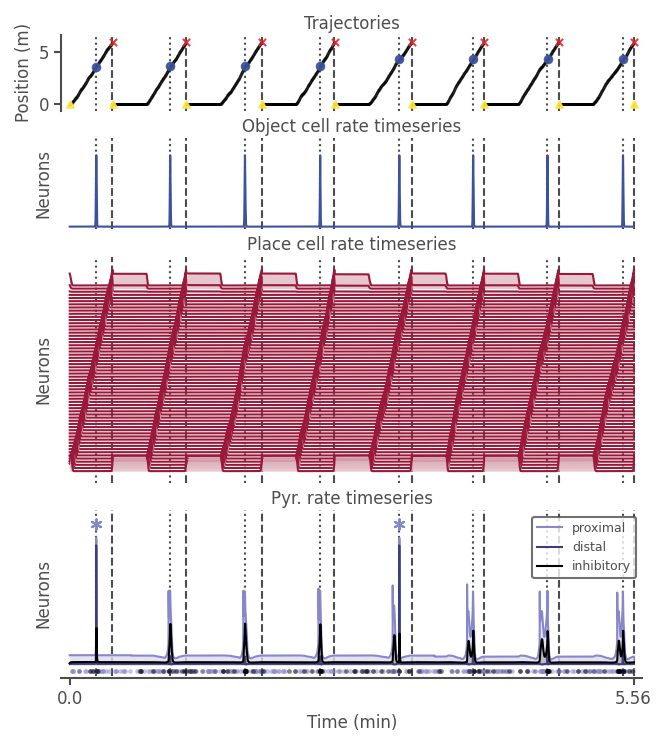

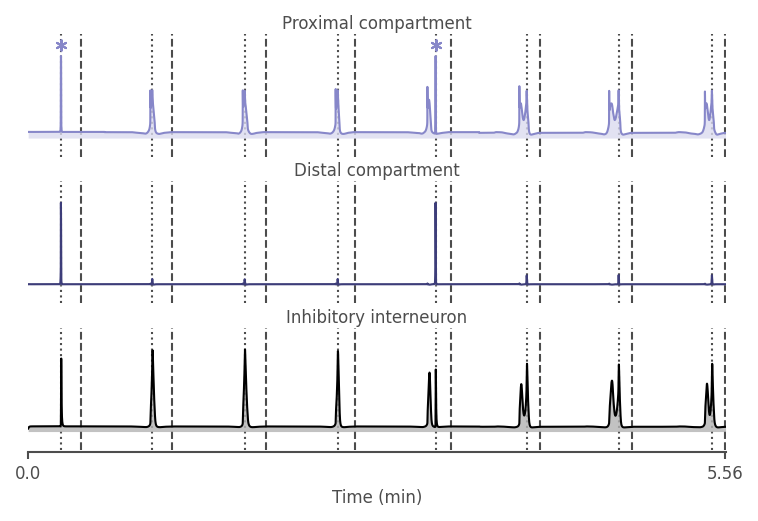

In [19]:
learner_shifted = Pyrs
NUM_SHIFTS = 1
shift = params_util.SHIFT_MID
for i in range(NUM_SHIFTS):
    shift_time = Ag.t
    shifted_landmark_position = Ag.shift_target_position(shift)
    
    learner_shifted = run_manager.learn_1D_BTSP(
        Pyrs_or_learner=learner_shifted,
        BTSP_on=None,
        num_traj_can_stop=4,
        plot=False
    )
    
time_axes = plot_fcts.plot_1D_time_info(learner_shifted.Pyrs)
time_axes.ravel()[-1].legend(loc="upper right")

ts_axes = learner_shifted.Pyrs.plot_rate_timeseries(separate_axes=True, Pyr_kwargs={"norm_by": "shared_max"})
for sub_ax in ts_axes.ravel():
    sub_ax.set_ylabel("")


ALL_FIGURES["2-shifted_time"] = time_axes
ALL_FIGURES["2-shifted_timeseries"] = ts_axes

### Shifted landmark groundtruth rate maps

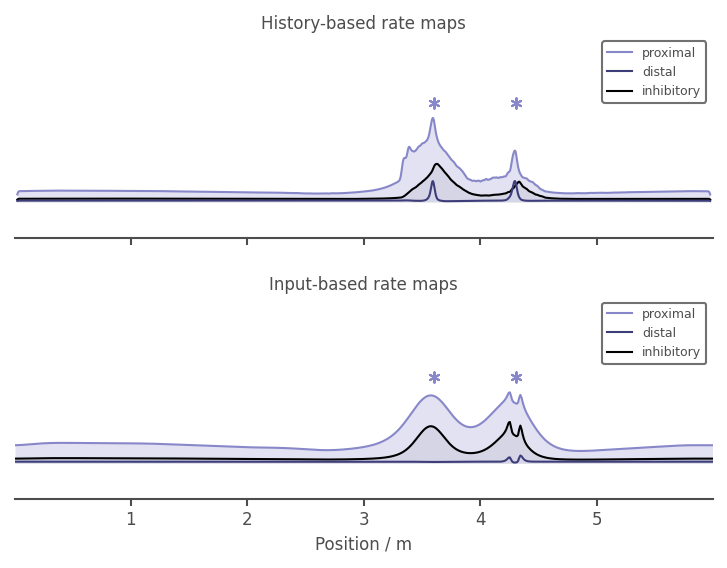

In [20]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True, gridspec_kw={"hspace": 0.3})
learner_shifted.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
ax1D[0].set_ylabel("")
ax1D[0].legend(loc="upper right")

learner_shifted.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Input-based rate maps")
ax1D[1].set_ylabel("")
ax1D[1].legend(loc="upper right")

ALL_FIGURES["2-shifted_rate_maps"] = ax1D

### Shifted landmark BTSP stats

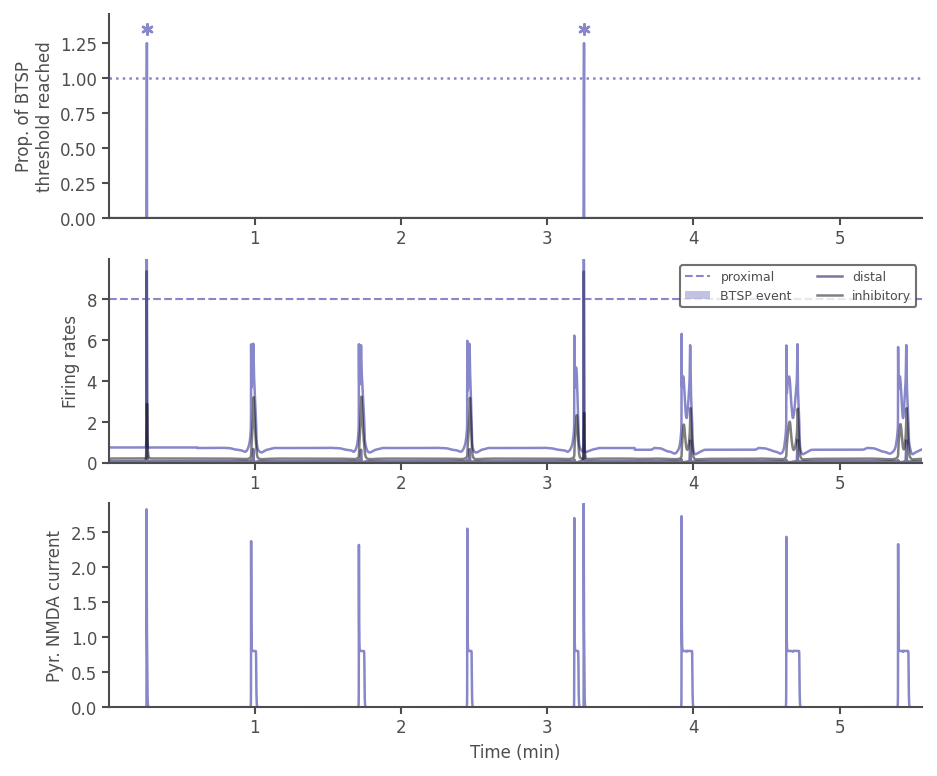

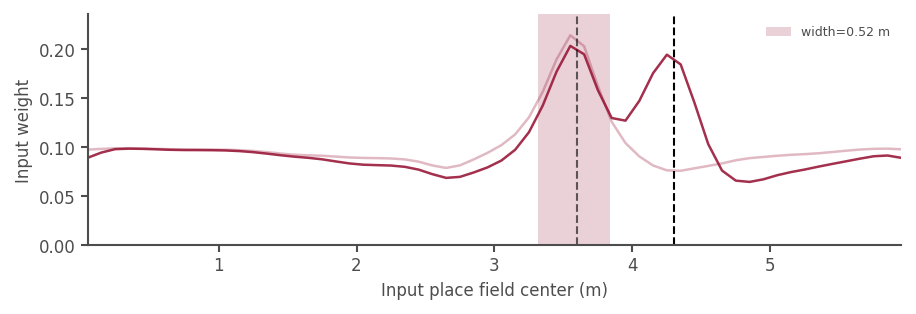

In [21]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_shifted.Pyrs, 
    recorded_PFs=learner_shifted.get_recorded_weights()["weights"][:, 0],
    target_position=shifted_landmark_position, 
    other_positions=[landmark_position],
    plot_last_width=True,
)

ALL_FIGURES["2-shifted_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["2-shifted_PC_weights"] = PCs_sub_ax

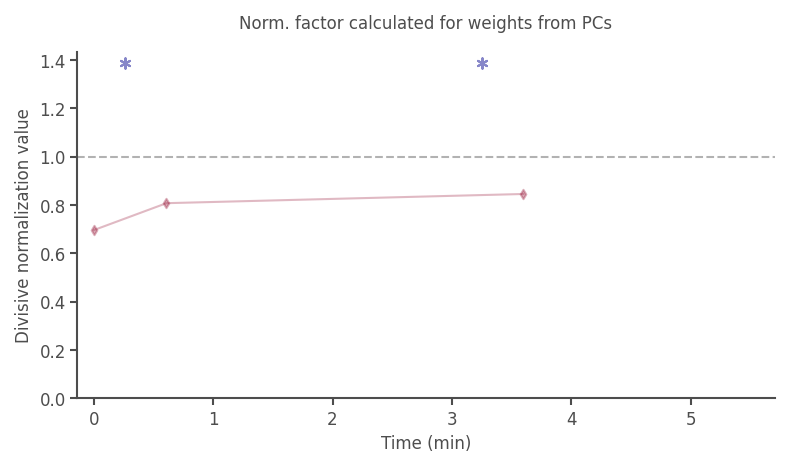

In [22]:
if learner_shifted.Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = learner_shifted.Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["2-shifted_weight_norm_time"] = sub_ax

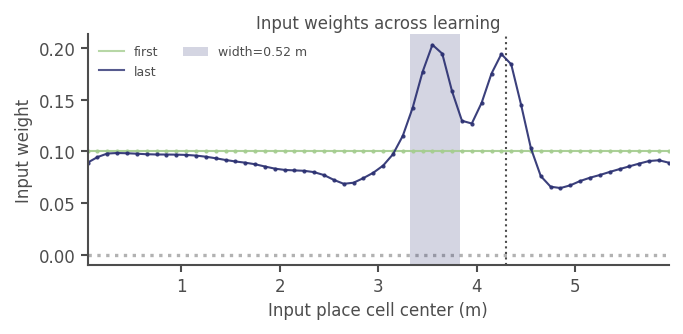

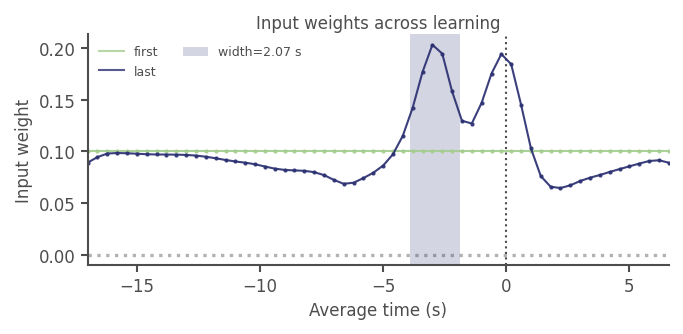

In [23]:
ws = [learner_shifted.Pyrs.ProximalCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_PFs(ws, PCs, plot_last_width=True)
sub_ax_time = plot_fcts.plot_1D_PFs(ws, PCs, time_axis=True, plot_last_width=True)

ALL_FIGURES["2-shifted_weights"] = sub_ax
ALL_FIGURES["2-shifted_weights_time"] = sub_ax_time

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered (num steps: 696, 696).


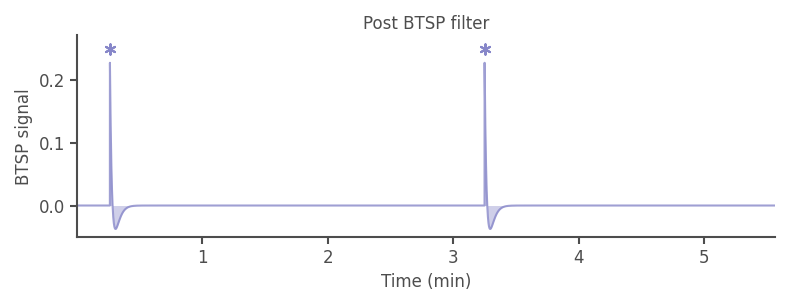

In [24]:
learner_shifted.Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_shifted.Pyrs.ProximalCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["2-shifted_post_BTSP_filter"] = sub_ax

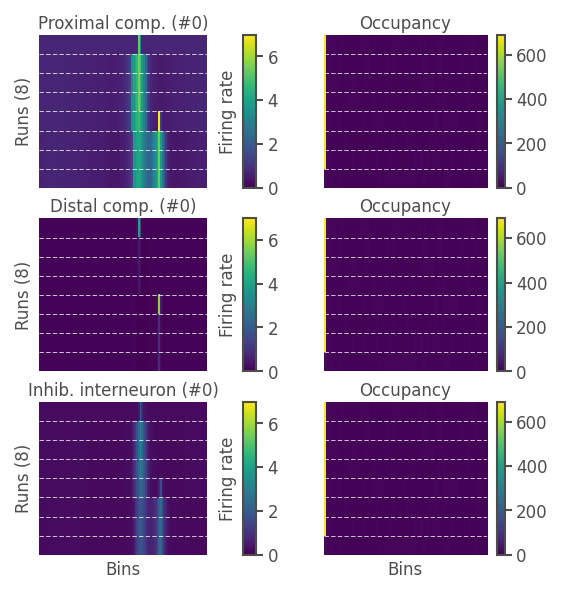

In [25]:
axes = learner_shifted.Pyrs.plot_binned_rates(mark_runs=True)
ALL_FIGURES["2-shifted_binned_rates"] = axes

## 3. Switch to back and forth navigation
Agent set to travel back and forth along the track.

0it [00:00, ?it/s]

Speed mean: 24.20 cm/s, std: 5.55 cm/s.
Reached target 8 times.
Trajectory lengths (16): 43.31 +/- 4.74 sec each
Trajectory lengths (16): 1443.75 +/- 157.90 steps each
0 BTSP events triggered (allowed from step 11128).
No weight normalization values recorded.


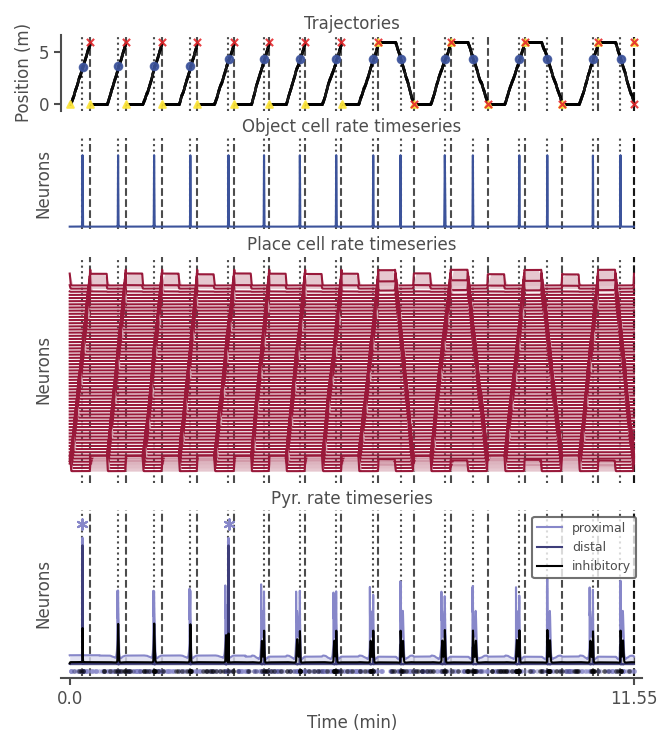

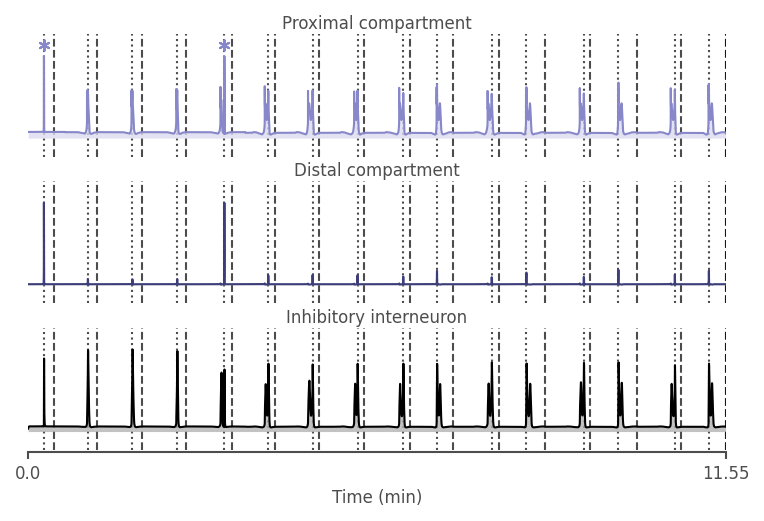

In [26]:
bf_start_time = Ag.t

learner_bf = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    BTSP_on=None,
    num_traj_can_stop=8,
    reverse=True,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_bf.Pyrs)
time_axes.ravel()[-1].legend(loc="upper right")

ts_axes = learner_bf.Pyrs.plot_rate_timeseries(separate_axes=True, Pyr_kwargs={"norm_by": "shared_max"})
for sub_ax in ts_axes.ravel():
    sub_ax.set_ylabel("")

ALL_FIGURES["3-back_forth_time"] = time_axes
ALL_FIGURES["3-back_forth_timeseries"] = ts_axes

### Back and forth track groundtruth rate maps

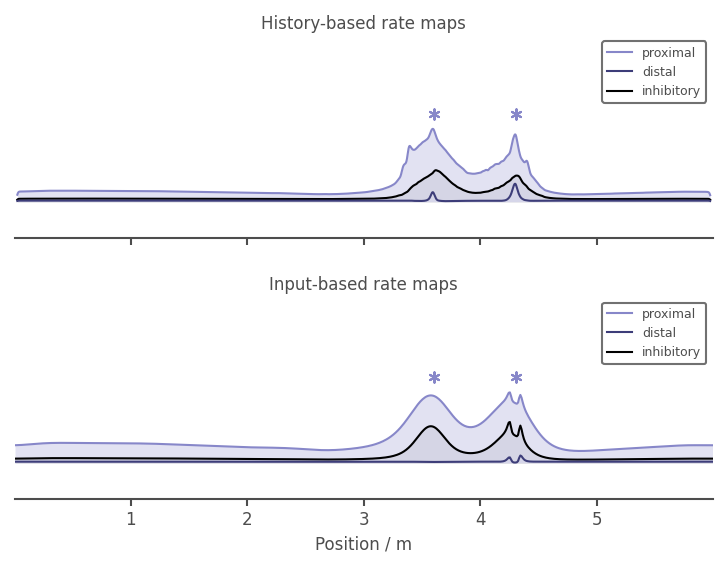

In [27]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True, gridspec_kw={"hspace": 0.3})
learner_bf.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
ax1D[0].set_ylabel("")
ax1D[0].legend(loc="upper right")

learner_bf.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Input-based rate maps")
ax1D[1].set_ylabel("")
ax1D[1].legend(loc="upper right")

ALL_FIGURES["3-back_forth_rate_maps"] = ax1D

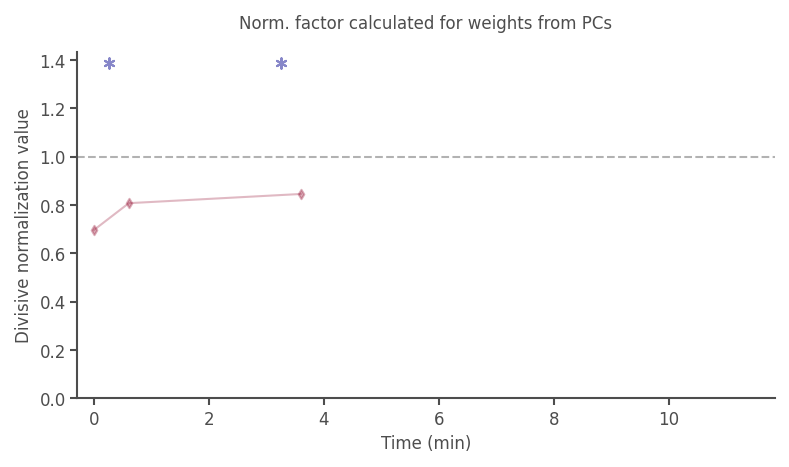

In [28]:
if learner_bf.Pyrs.ProximalCompartment.normalize_weights_divisively:
    sub_ax = learner_bf.Pyrs.ProximalCompartment.plot_normalization_values(input_layer="PCs")
    ALL_FIGURES["3-back_forth__weight_norm_time"] = sub_ax

### Back and forth track BTSP stats

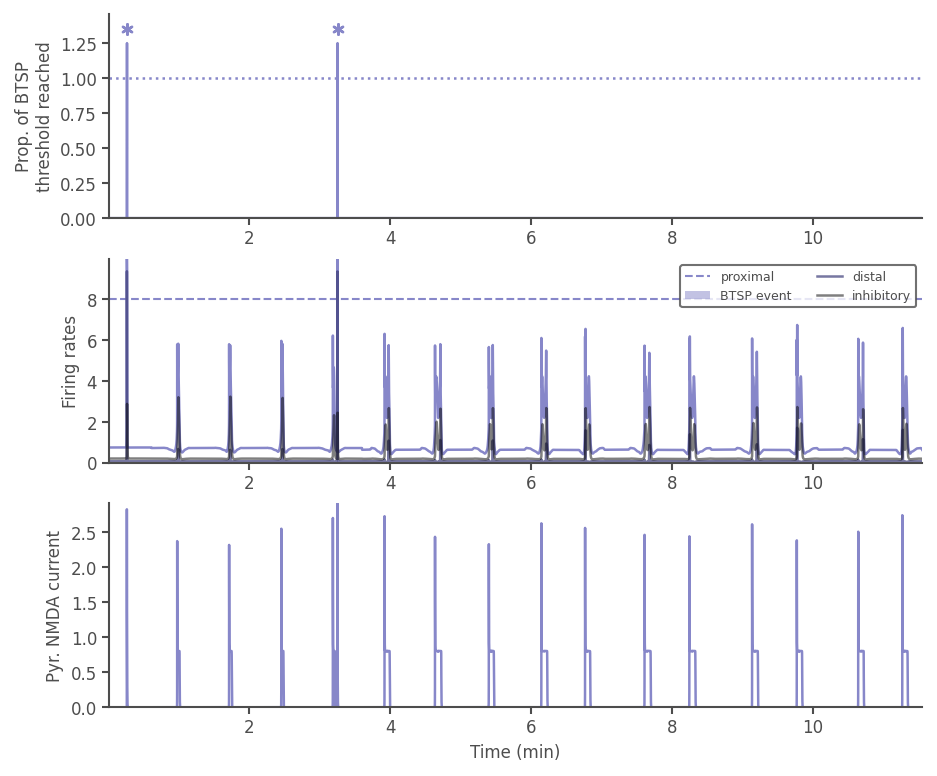

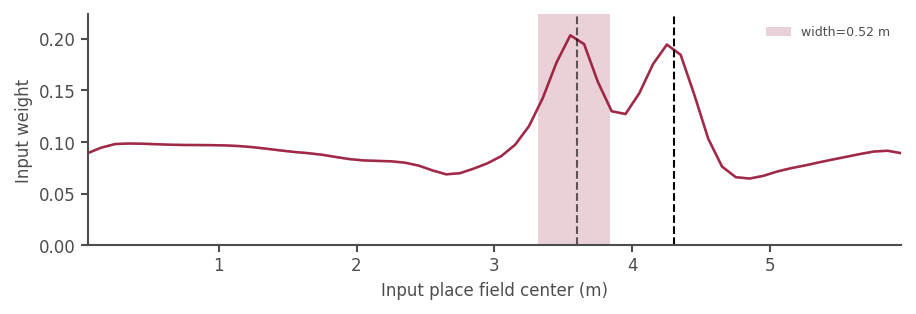

In [29]:
BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
    learner_bf.Pyrs, 
    recorded_PFs=learner_bf.get_recorded_weights()["weights"][:, 0],
    target_position=shifted_landmark_position, 
    other_positions=[landmark_position],
    plot_last_width=True
)

ALL_FIGURES["3-back_forth_BTSP_timeseries"] = BTSP_ramp_ax1D
ALL_FIGURES["3-back_forth_PC_weights"] = PCs_sub_ax

BTSP updates applied on average 696.00 steps (20.88 sec.) after they were triggered (num steps: 696, 696).


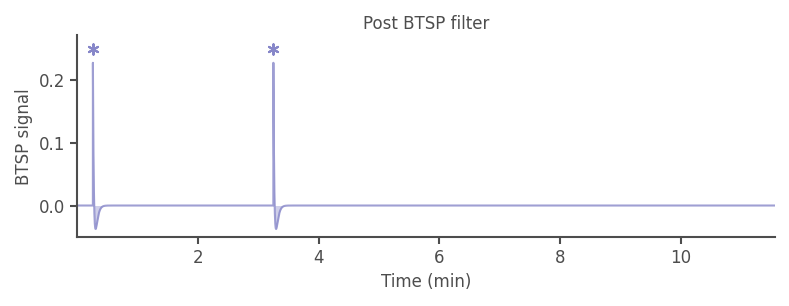

In [30]:
learner_bf.Pyrs.ProximalCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_bf.Pyrs.ProximalCompartment.plot_filtered_for_BTSP()

ALL_FIGURES["3-back_forth_post_BTSP_filter"] = sub_ax

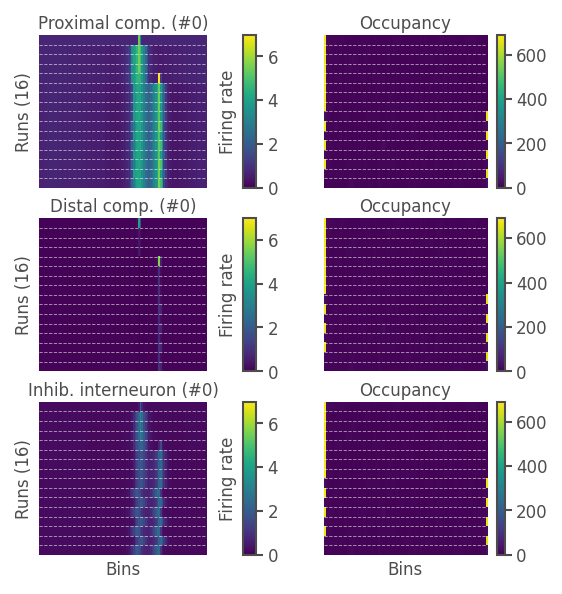

In [31]:
axes = learner_bf.Pyrs.plot_binned_rates(mark_runs=True)

ALL_FIGURES["3-back_forth_binned_rates"] = axes

## 4. Remove landmark object from track
Landmark object removed from track.

0it [00:00, ?it/s]

Speed mean: 24.26 cm/s, std: 5.51 cm/s.
Reached target 4 times.
Trajectory lengths (20): 43.50 +/- 4.26 sec each
Trajectory lengths (20): 1450.00 +/- 141.96 steps each
0 BTSP events triggered (allowed from step 23101).
No weight normalization values recorded.
\Landmark removed.


0it [00:00, ?it/s]

Speed mean: 24.47 cm/s, std: 5.54 cm/s.
Reached target 0 times.
Trajectory lengths (24): 43.45 +/- 3.90 sec each
Trajectory lengths (24): 1448.50 +/- 129.97 steps each
0 BTSP events triggered (allowed from step 29002).
No weight normalization values recorded.


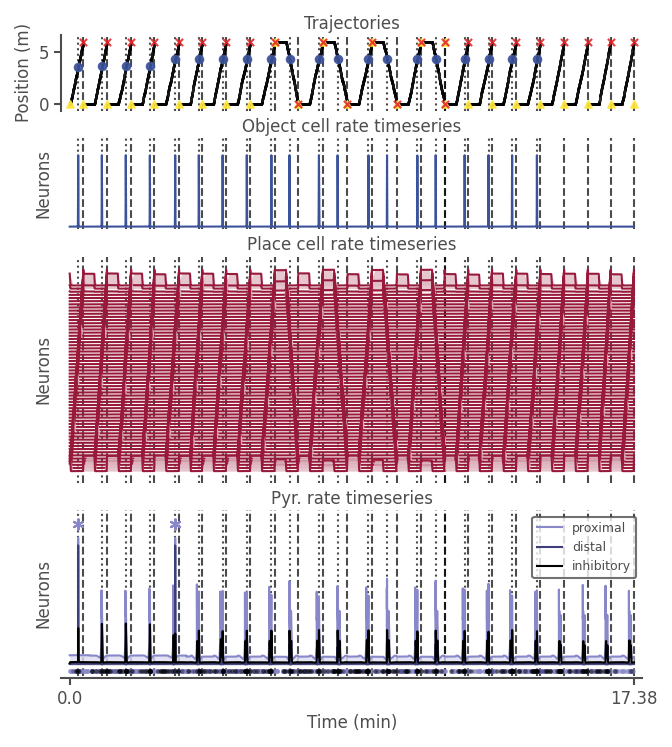

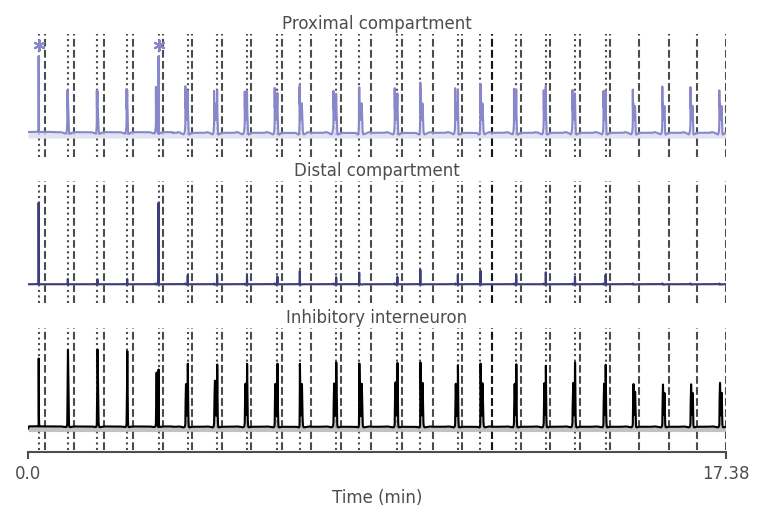

In [32]:
pre_removed_time = Ag.t
learner_pre_removed = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    BTSP_on=None,
    num_traj_can_stop=4,
    plot=False
)

print("\Landmark removed.")
Ag.target_position = None
removed_time = Ag.t
        
learner_post_removed = run_manager.learn_1D_BTSP(
    Pyrs_or_learner=Pyrs,
    BTSP_on=None,
    num_traj_can_stop=4,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_post_removed.Pyrs)
time_axes.ravel()[-1].legend(loc="upper right")

ts_axes = learner_post_removed.Pyrs.plot_rate_timeseries(separate_axes=True, Pyr_kwargs={"norm_by": "shared_max"})
for sub_ax in ts_axes.ravel():
    sub_ax.set_ylabel("")

ALL_FIGURES["4-removed_time"] = time_axes
ALL_FIGURES["4-removed_timeseries"] = ts_axes

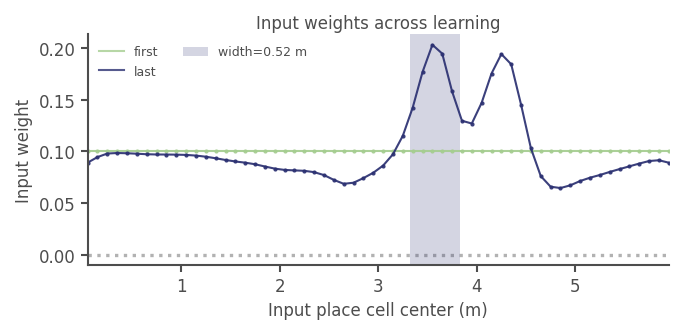

In [33]:
ws = [Pyrs.ProximalCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_PFs(ws, PCs, plot_last_width=True)

ALL_FIGURES["4-removed_weights"] = sub_ax

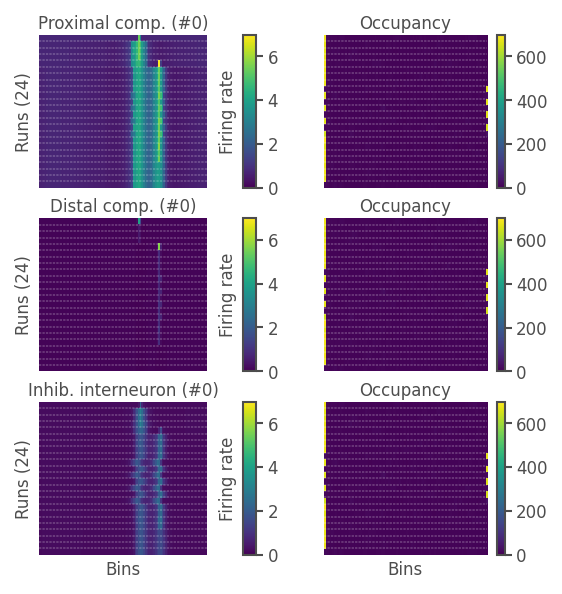

In [34]:
axes = Pyrs.plot_binned_rates(mark_runs=True)

ALL_FIGURES["4-removed_binned_rates"] = axes

## Before / After

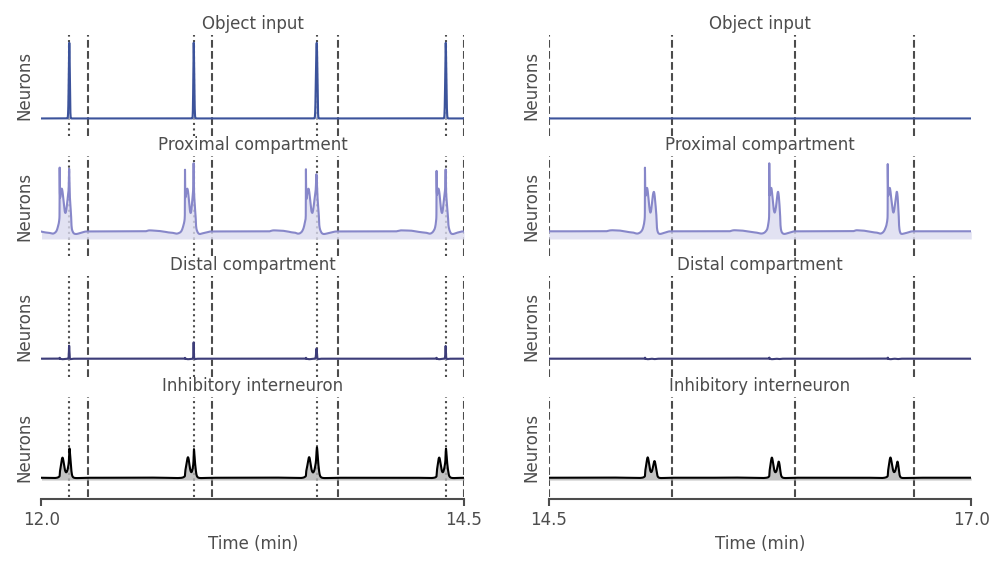

In [35]:
axes = plot_fcts.plot_pre_post_responses(Pyrs, Objs, ref_time=removed_time, pre=2.5 * 60)
ALL_FIGURES["4-removed_pre_post"] = axes

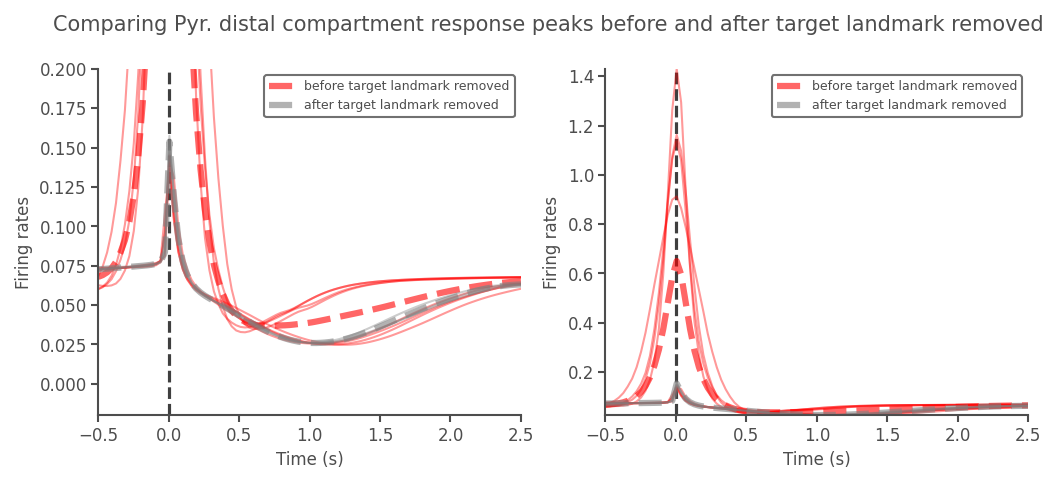

In [36]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=False)

pre = 2.5 * 60
pts_btw = 100
all_ylims = [(-0.02, 0.2), None]

for i, ylims in enumerate(all_ylims):
    plot_fcts.plot_pre_post_distal_peaks(
        Pyrs, 
        ref_time=removed_time, 
        pre=pre,
        ylims=ylims,
        together=True, 
        label="target landmark removed", 
        ax=ax1D[i],
        pts_btw=pts_btw
    )
    ax1D[i].legend(loc="upper right")

ALL_FIGURES["4-removed_pre_post_distal"] = ax1D

## 5. Change running speed

In [37]:
def get_speed(speed="slow", no_noise=False):
    
    if speed == "slow":
        speed_mean = 0.15
        speed_std = 0.02
    elif speed == "fast":
        speed_mean = 0.35
        speed_std = 0.02
    elif speed == "variable":
        speed_mean = params_util.SPEED_MEAN_LINEAR
        speed_std = speed_mean
    else:
        raise ValueError(f"speed {speed} not recognized.")

    if no_noise:
        speed_std = 0
    
    return speed_mean, speed_std

In [38]:
def run_speed_learner(speed="variable"):

    speed_mean, speed_std = get_speed(speed, no_noise=True)

    env_params = params_util.get_env_params(
        environment="linear",
        init_env_object_prop=params_util.REL_ENV_OBJECT_POS,
    )
    
    agent_params = params_util.get_agent_params(
        environment="linear",
        speed_mean=speed_mean,
        speed_std=speed_std,
        wait_after_trajectory=0,
    )

    init_kwargs = {
        "agent_params": agent_params,
        "Pyr_params": Pyr_params,
        }

    learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
        init_kwargs=init_kwargs,
        BTSP_on=None,
        num_traj_can_stop=8,
        plot=True
    )
    learner.Agent.log_speed_stats(ignore_near_zero=True)

    ts_axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyr_kwargs={"norm_by": "shared_max"})
    for sub_ax in ts_axes.ravel():
        sub_ax.set_ylabel("")

    spatial_axes.ravel()[-2].legend(loc="upper right")
    time_axes.ravel()[-1].legend(loc="upper right")

    BTSP_ramp_ax1D, PCs_sub_ax = plot_fcts.plot_1D_BTSP_stats(
        learner.Pyrs, 
        recorded_PFs=learner.get_recorded_weights()["weights"][:, 0], 
        target_position=learner.Agent.target_position,
        plot_last_width=True
    )

    BTSP_speed_sub_ax = learner.Pyrs.ProximalCompartment.plot_around_BTSP(datatype="speed")

    binned_rates_axes = learner.Pyrs.ProximalCompartment.plot_binned_rates(vel_sign_smooth=35, mark_runs=True) # high threshold

    subplot_dict = {
        "spatial": spatial_axes,
        "time": time_axes,
        "timeseries": ts_axes,
        "BTSP_timeseries": BTSP_ramp_ax1D,
        "PC_weights": PCs_sub_ax,
        "BTSP_speed": BTSP_speed_sub_ax,
        "binned_rates": binned_rates_axes
    }

    return learner, subplot_dict

Running at slow speed.


0it [00:00, ?it/s]

BTSP event recorded at step 815 (24.45 sec).
BTSP update applied at step 1509 (45.27 sec).
Speed mean: 14.76 cm/s, std: 1.29 cm/s.
Reached target 8 times.
Trajectory lengths (8): 40.28 +/- 0.02 sec each
Trajectory lengths (8): 1342.75 +/- 0.66 steps each
1 BTSP event triggered (allowed from step 0): occurred at step 815.
No weight normalization applied (max value of 0.8442 <= 1).
Speed mean: 14.76 cm/s, std: 1.29 cm/s.

Running at fast speed.


0it [00:00, ?it/s]

BTSP event recorded at step 364 (10.92 sec).
BTSP update applied at step 1058 (31.74 sec).
Speed mean: 33.70 cm/s, std: 4.49 cm/s.
Reached target 8 times.
Trajectory lengths (8): 17.66 +/- 0.02 sec each
Trajectory lengths (8): 588.75 +/- 0.83 steps each
1 BTSP event triggered (allowed from step 0): occurred at step 364.
No weight normalization applied (max value of 0.7771 <= 1).
Speed mean: 33.70 cm/s, std: 4.49 cm/s.

Running at variable speed.


0it [00:00, ?it/s]

BTSP event recorded at step 499 (14.97 sec).
BTSP update applied at step 1193 (35.79 sec).
Speed mean: 24.33 cm/s, std: 2.74 cm/s.
Reached target 8 times.
Trajectory lengths (8): 24.45 +/- 0.02 sec each
Trajectory lengths (8): 814.88 +/- 0.60 steps each
1 BTSP event triggered (allowed from step 0): occurred at step 499.
No weight normalization applied (max value of 0.8019 <= 1).
Speed mean: 24.33 cm/s, std: 2.74 cm/s.


/home/cgillon/homedir/predhpc/predhpc/util/plot_util.py:1908: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axes = plt.subplots(


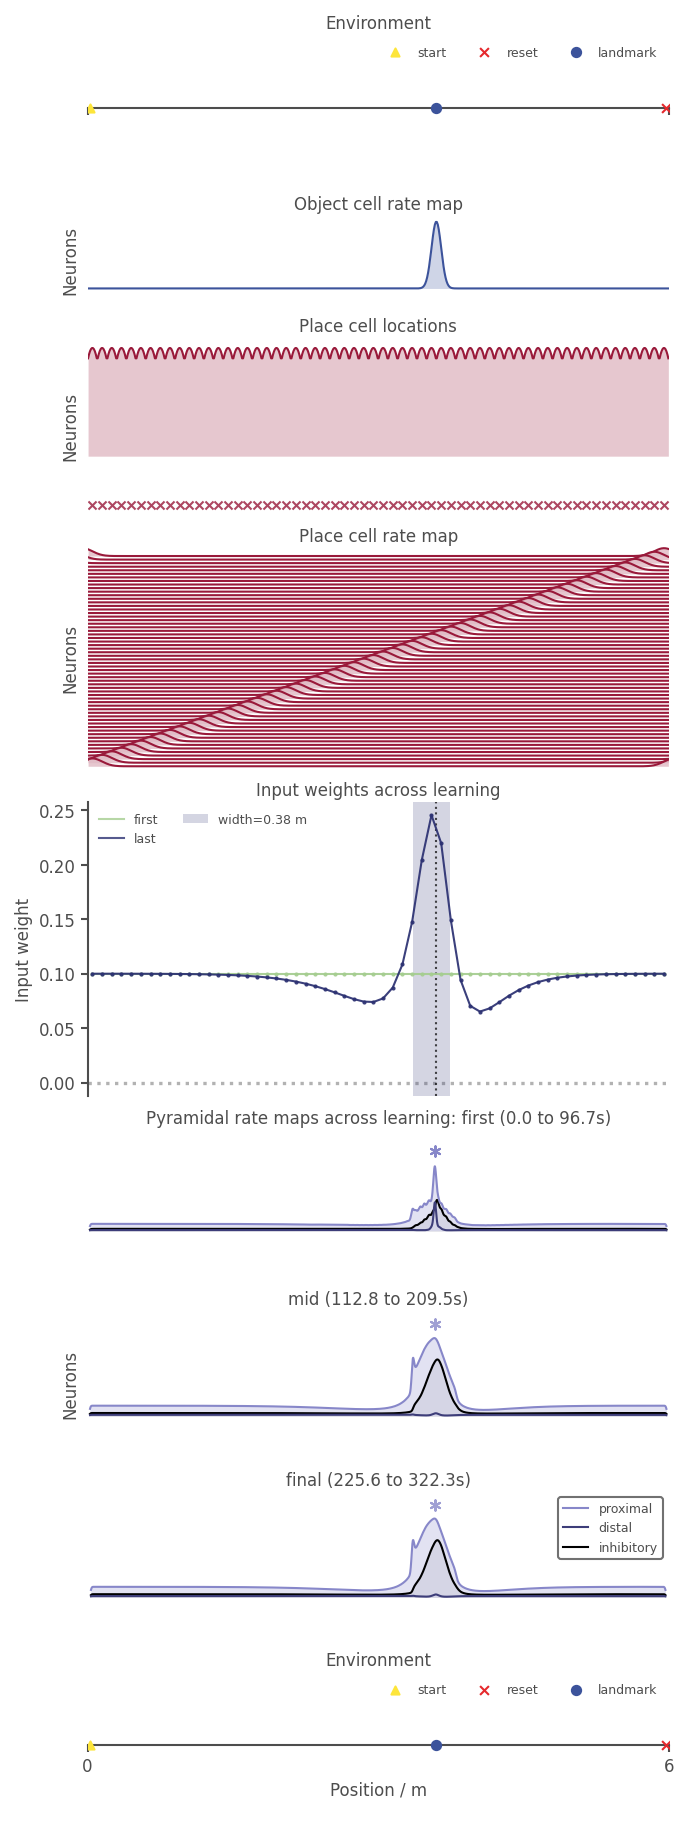

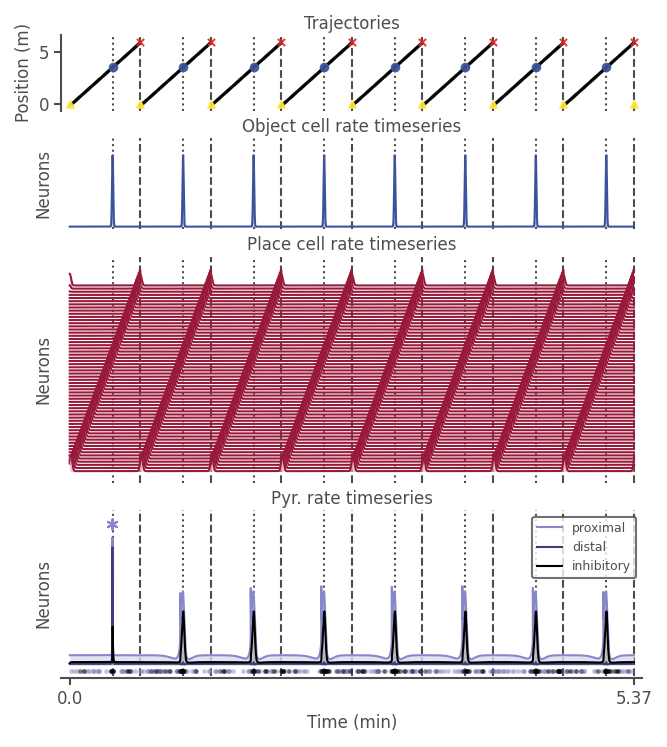

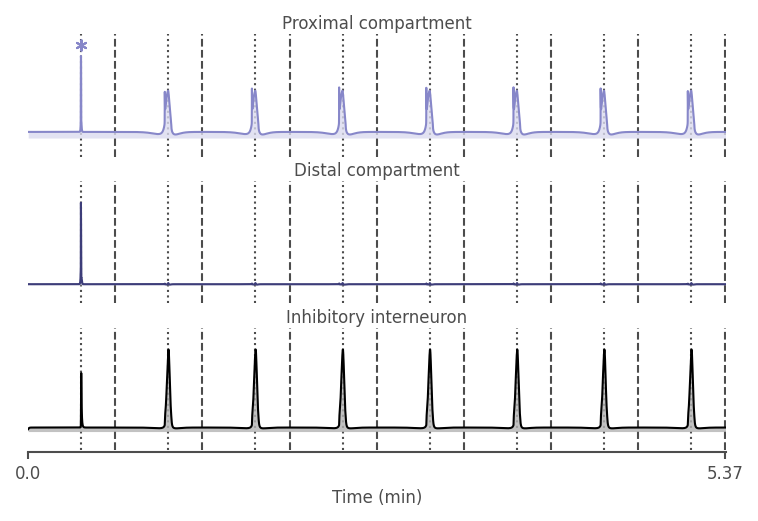

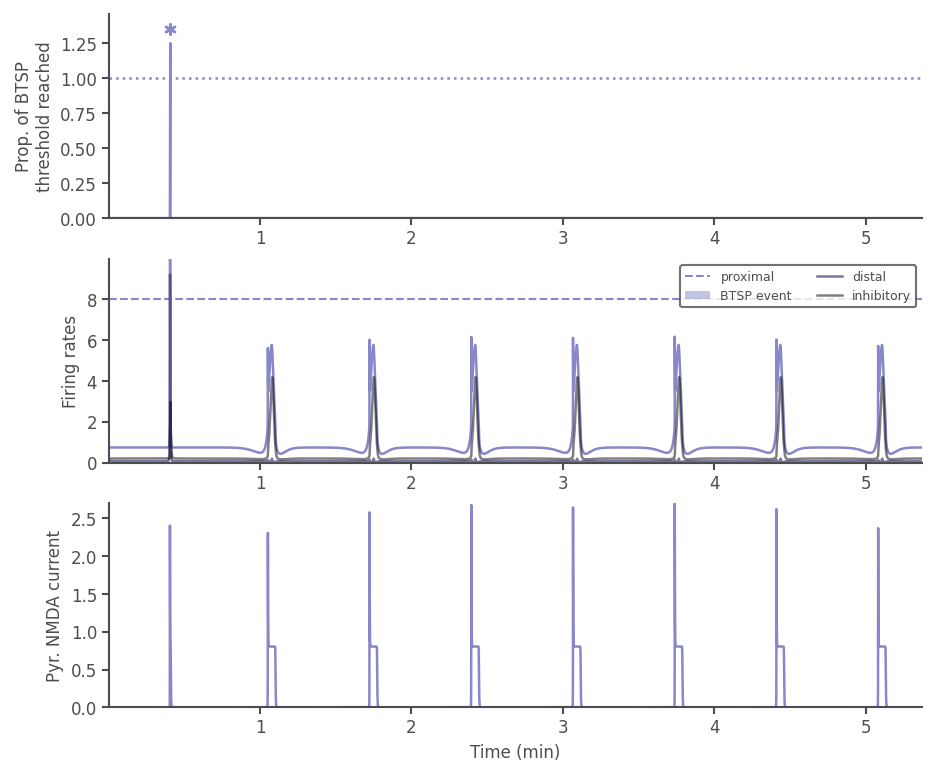

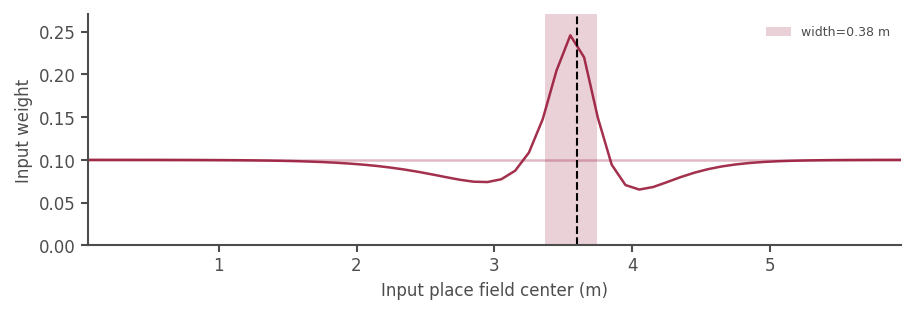

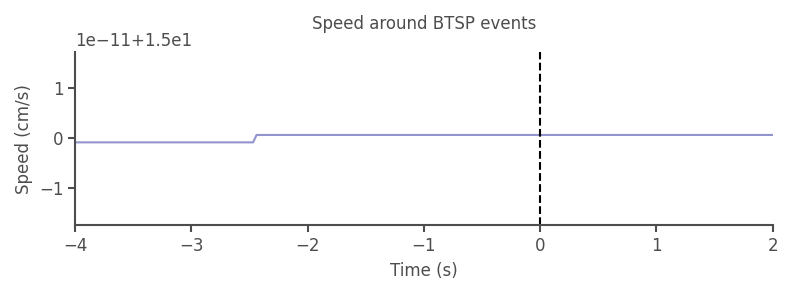

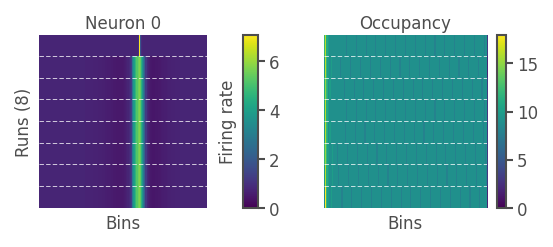

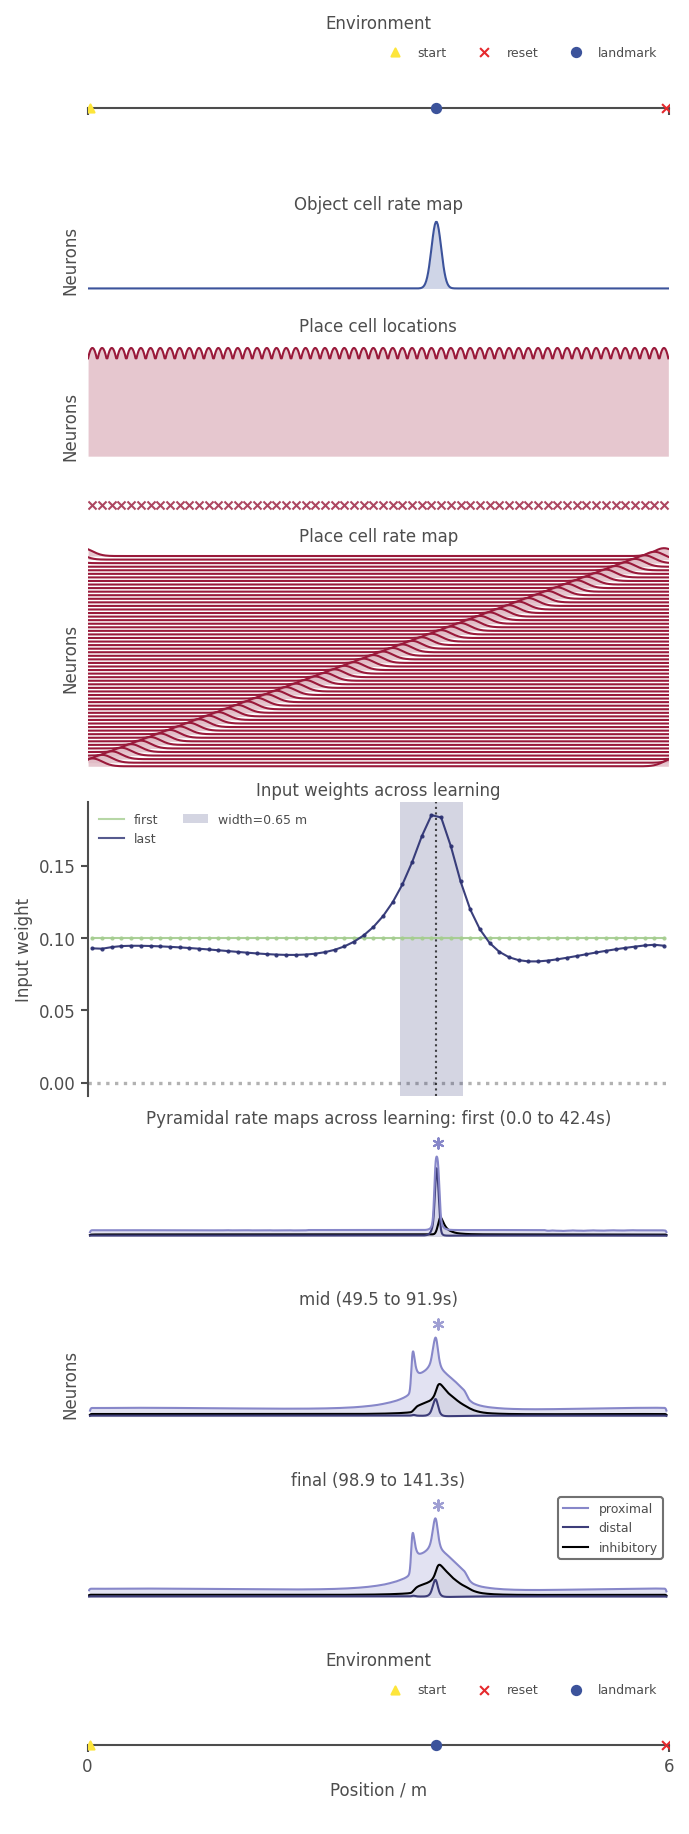

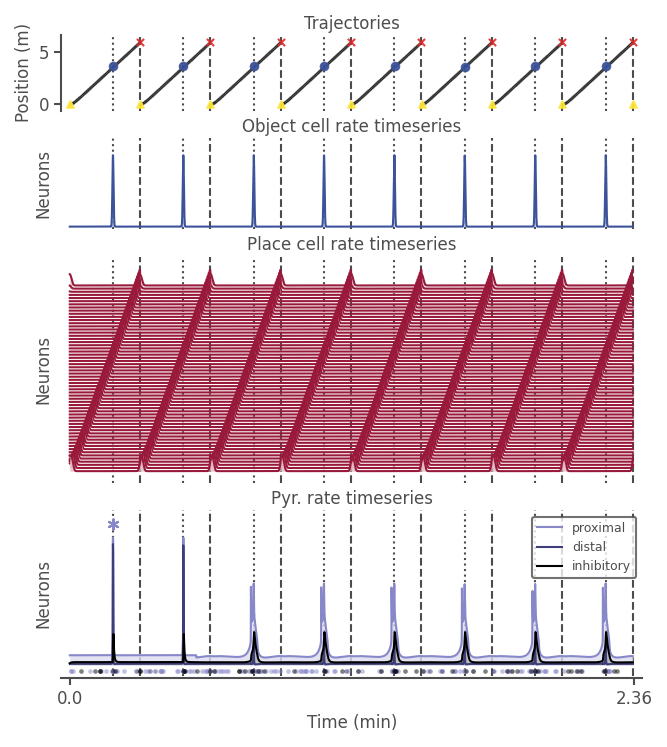

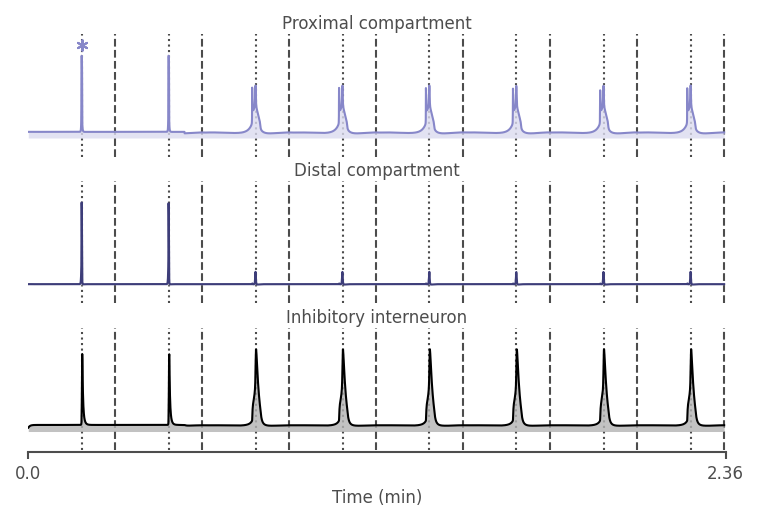

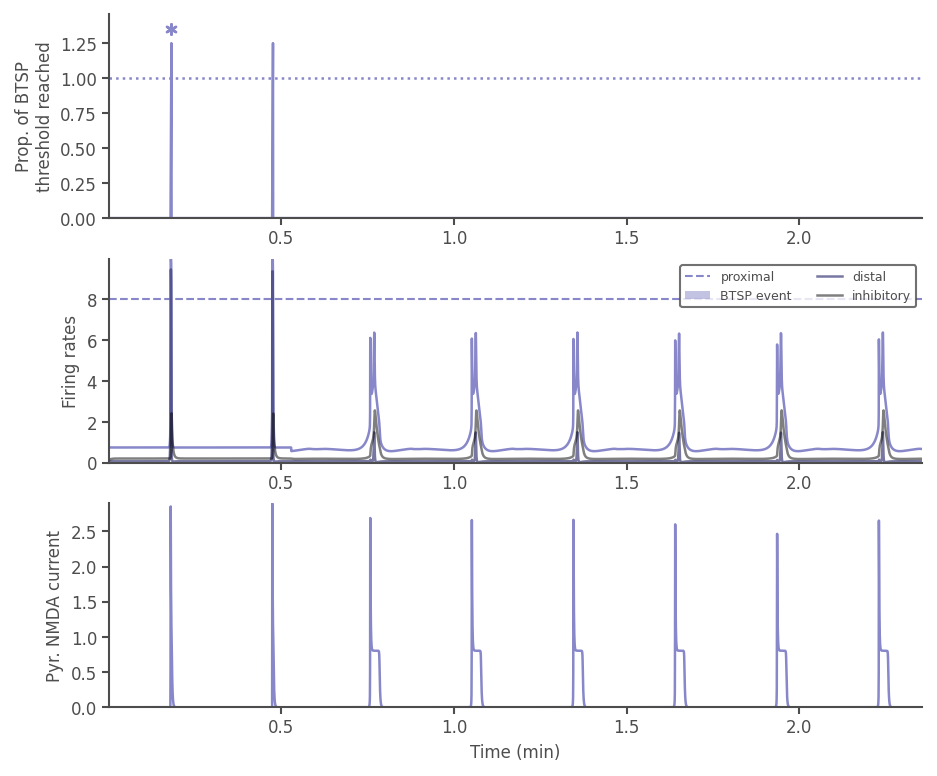

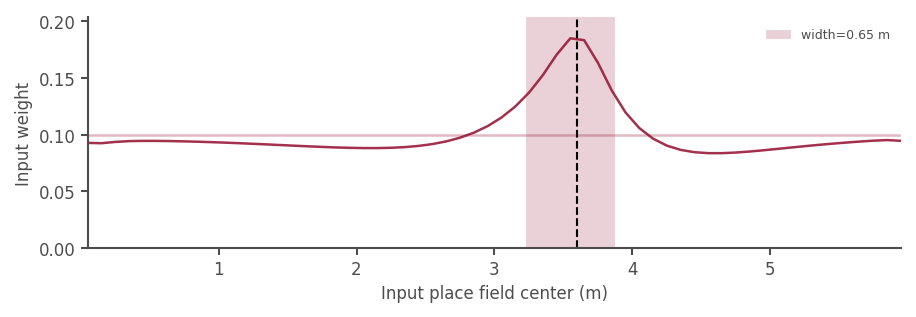

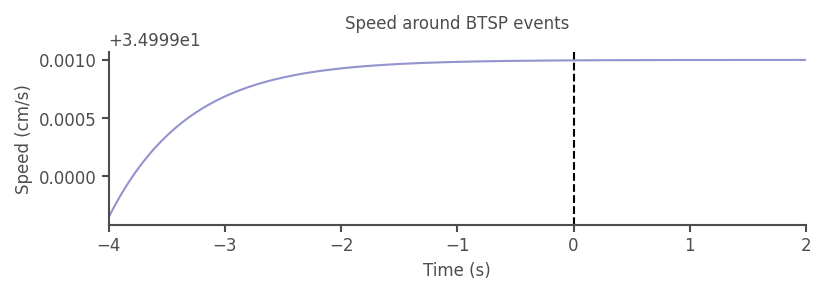

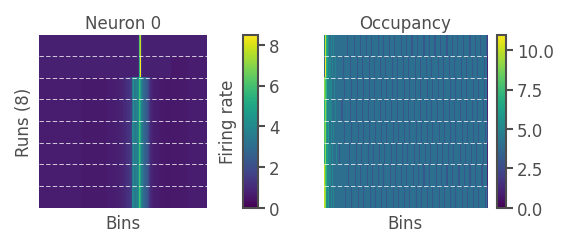

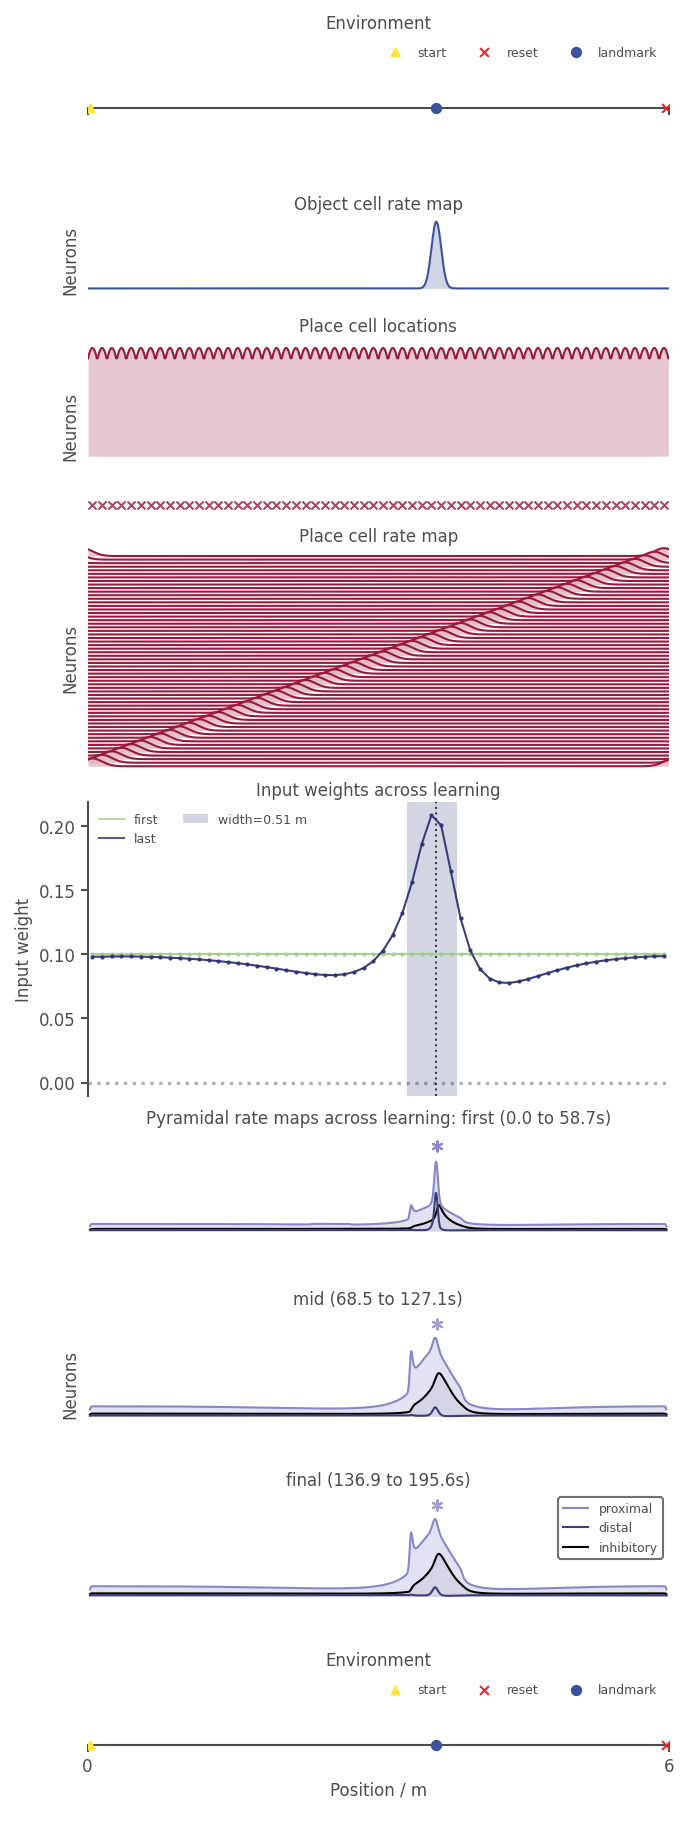

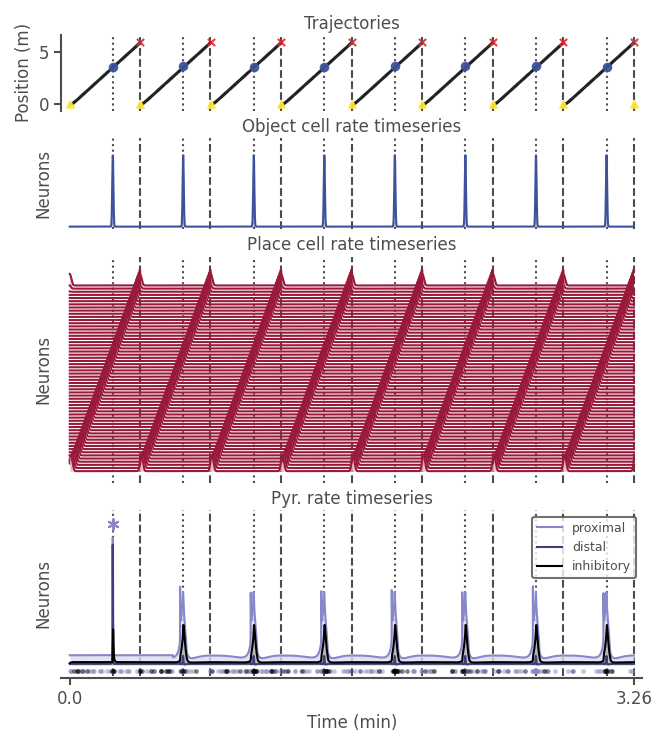

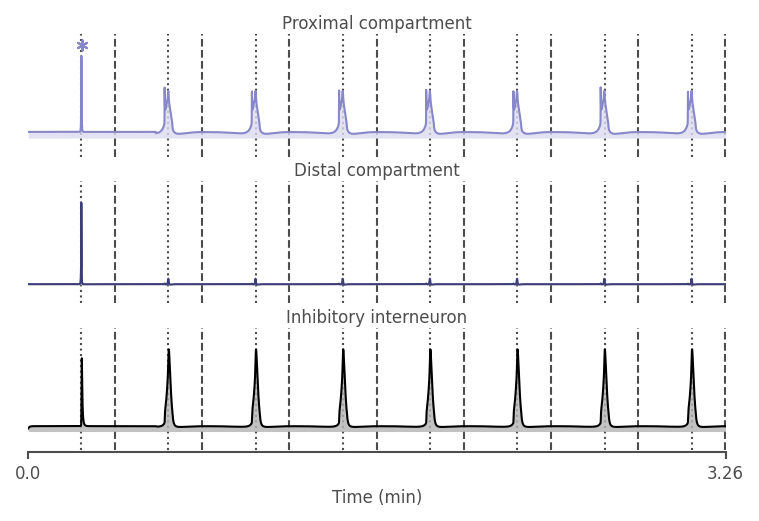

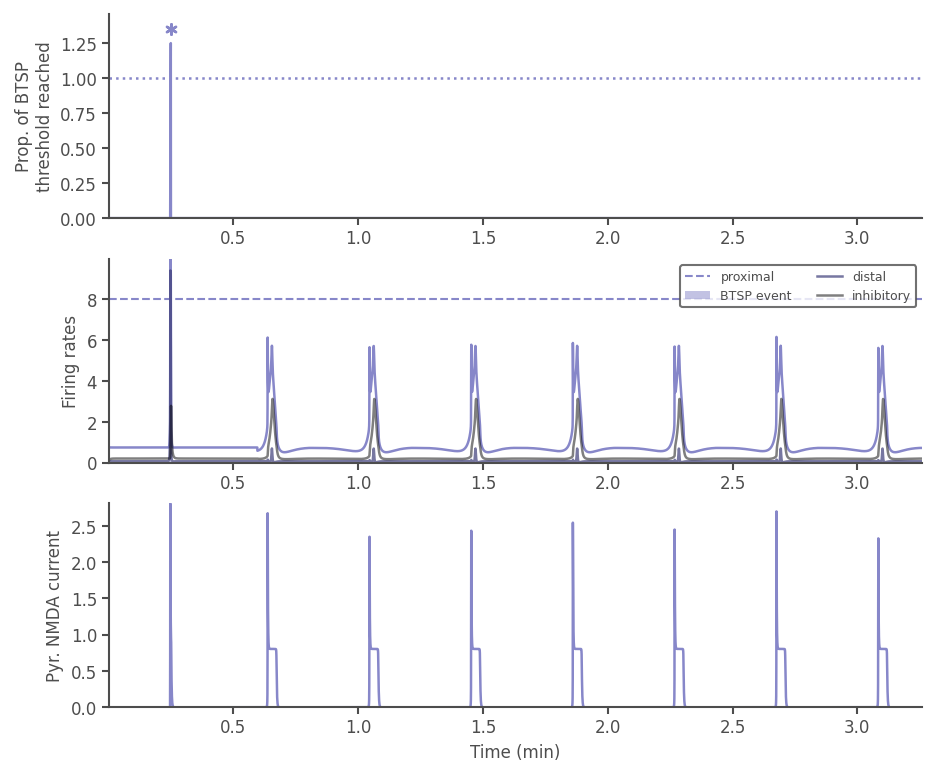

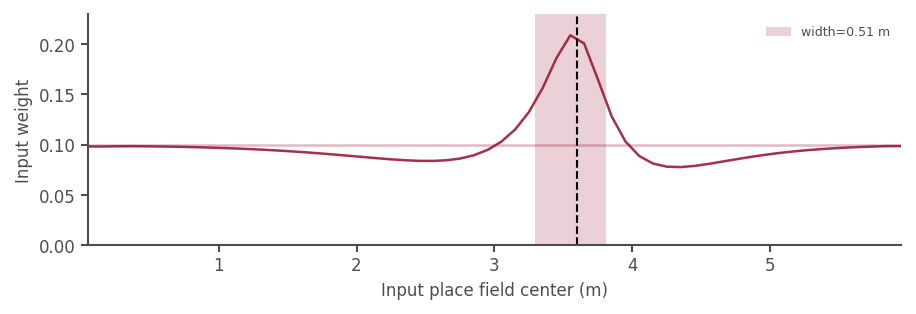

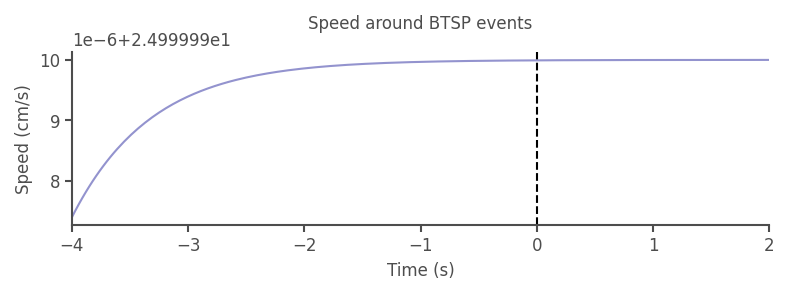

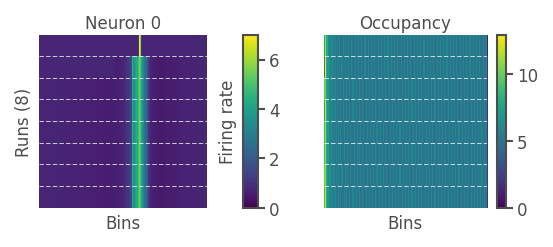

In [39]:
speed_learners_all = list()
for i, speed in enumerate(["slow", "fast", "variable"]):
    space = "\n" if i > 0 else ""
    print(f"{space}Running at {speed} speed.")

    speed_learner, subplot_dict = run_speed_learner(speed)
    speed_learners_all.append(speed_learner)

    for name, subplots in subplot_dict.items():
        ALL_FIGURES[f"5-{name}_{speed}"] = subplots

## 6. Save and animate

### Save figures

In [40]:
SAVE = True

In [ ]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, save=True)

### Animate

In [42]:
ANIMATE = True

In [43]:
if ANIMATE:
    all_learners = [
        learner, 
        learner_shifted, 
        learner_bf, 
        learner_pre_removed, 
        learner_post_removed
    ]

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in all_learners]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }
    
    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["times"],
        "fps": 8,
        "speed_up": 5,
        "embed_limit": 40.0,
        "anim_save_types": ["mp4"],
        "autosave": True,
    }
    
    if (Ag.start_position > Ag.reset_position).all():
        Ag.reverse()

### 1-Initial conditions
Animation takes about 2 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=shift_time, 
        savename="1-initial_timeseries",
        addendum="initial direction",
        **all_animate_kwargs
        )
    anim

### 2-Target landmark shifted
Animation takes about 2 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=shift_time, 
        t_end=bf_start_time, 
        savename="2-shifted_timeseries",
        addendum="landmark moved",
        **all_animate_kwargs
        )
    anim

### 3-Back and forth
Animation takes about 4 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=bf_start_time, 
        t_end=pre_removed_time, 
        savename="3-back_forth_timeseries",
        addendum="back and forth",
        **all_animate_kwargs
        )
    anim

### 4-Target landmark removed
Animation takes about 4 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=pre_removed_time, 
        t_end=None, 
        savename="4-removed_timeseries",
        addendum="landmark removed",
        **all_animate_kwargs
        )
    anim

### Full
Animation takes about 10 min to create.

In [ ]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=None, 
        savename="full_timeseries",
        **all_animate_kwargs
        )
    anim